In [1]:
!nvidia-smi

Mon Oct  5 06:03:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install -q diffusers transformers accelerate safetensors

In [3]:
import torch
from diffusers import StableDiffusionPipeline
from IPython.display import display

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

Device: cuda


In [5]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

In [7]:
prompt = "A beautiful futuristic city at sunset, highly detailed, cinematic lighting"

In [8]:
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

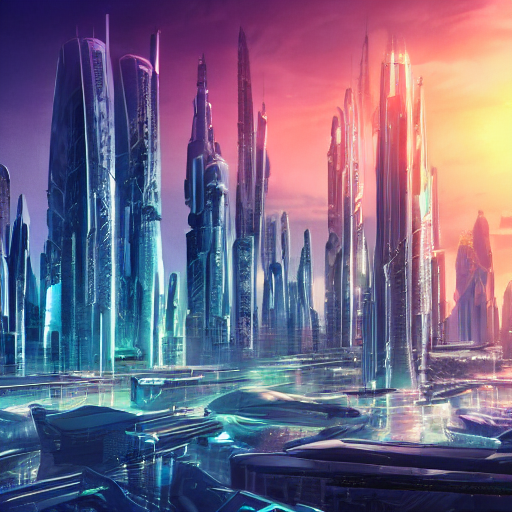

In [9]:
display(image)

In [10]:
image.save("generated_image.png")

  0%|          | 0/50 [00:00<?, ?it/s]

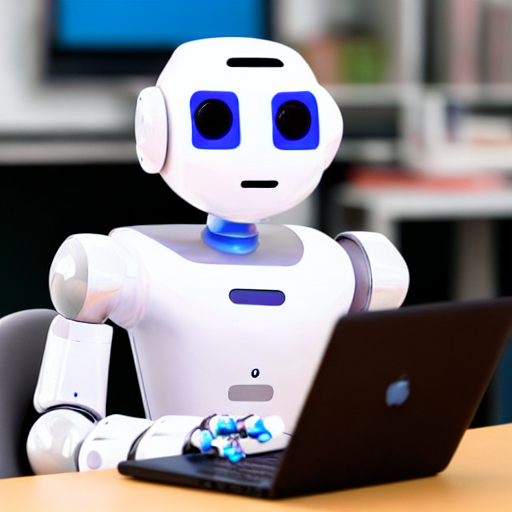

In [11]:
prompt = "A cute robot studying computer science in a modern classroom"
image = pipe(prompt).images[0]
display(image)

  0%|          | 0/50 [00:00<?, ?it/s]

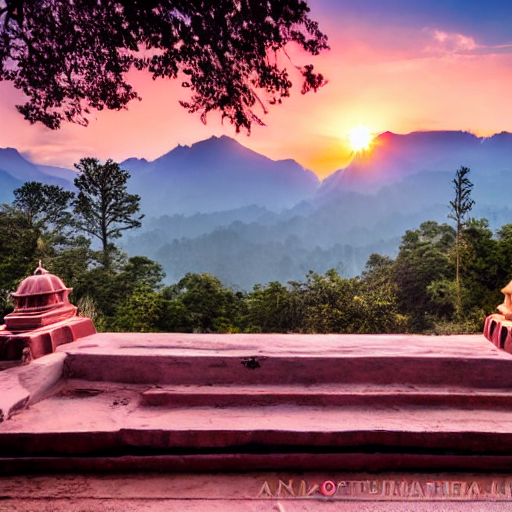

In [12]:
prompt = "A beautiful Indian temple surrounded by mountains, sunrise, realistic photography"
image = pipe(prompt).images[0]
display(image)

  0%|          | 0/50 [00:00<?, ?it/s]

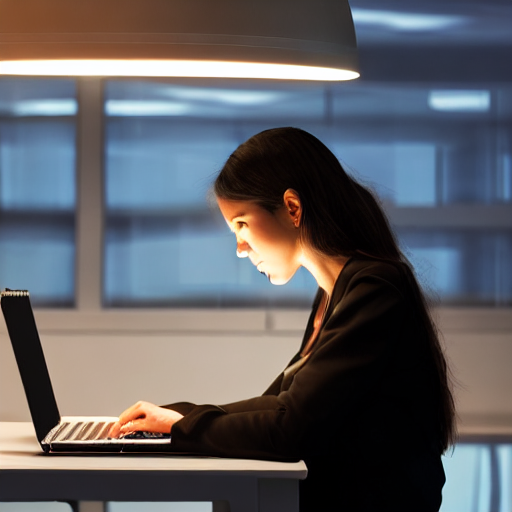

In [13]:
prompt = "A futuristic woman working on a laptop in a high-tech office, cinematic lighting"
image = pipe(prompt).images[0]
display(image)

  0%|          | 0/50 [00:00<?, ?it/s]

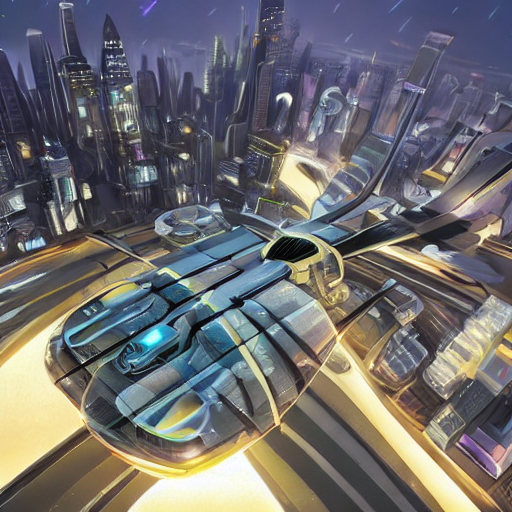

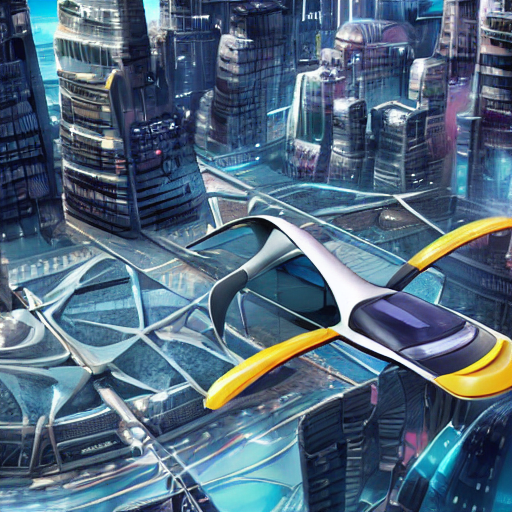

In [14]:
prompt = "A futuristic city with flying cars, cinematic, highly detailed"

images = pipe(
    prompt,
    num_images_per_prompt=2
).images

for i, img in enumerate(images):
    display(img)
    img.save(f"generated_image_{i+1}.png")

  0%|          | 0/30 [00:00<?, ?it/s]

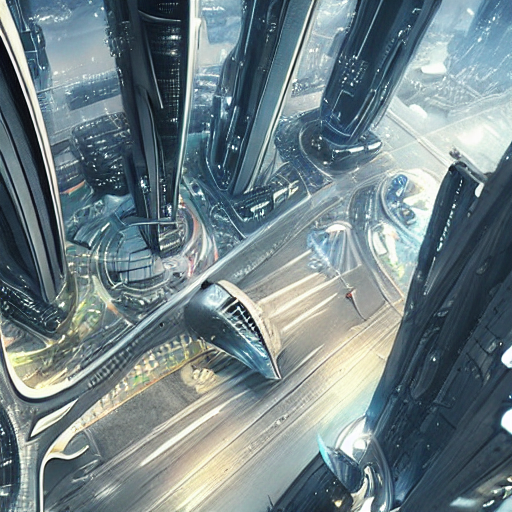

In [15]:
image = pipe(
    prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

display(image)